In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import datetime, nltk, warnings
import matplotlib.cm as cm
import itertools


from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn import preprocessing, model_selection, metrics, feature_selection
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix
from sklearn import neighbors, linear_model, svm, tree, ensemble
from wordcloud import WordCloud, STOPWORDS
from sklearn.ensemble import AdaBoostClassifier
from sklearn.decomposition import PCA
from IPython.display import display, HTML
# import plotly.plotly as py
import plotly.graph_objs as go

from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)



%matplotlib inline


## Config DataSet

In [3]:
data_set = pd.read_csv("dataset/data.csv", encoding= "ISO-8859-1", dtype= {"InvoiceNo": str, "CustomerID": str})

data_set.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [4]:
data_set.shape

(541909, 8)

- Tất cả có `541909` số lần giao dịch và có `8` cột

In [5]:
data_set["InvoiceDate"] = pd.to_datetime(data_set["InvoiceDate"]) # Chuyển `InvoiceDate` đúng form của DateTime trong python 

# Dọn sạch dữ liệu

## Dọn các cột có giá trị null

- SỐ lượng giá trị null cho mỗi cột

In [6]:
col_info = pd.DataFrame(data_set.dtypes).T.rename(index = {0:"column type"})
col_info = pd.concat([col_info,
                      pd.DataFrame(data_set.isnull().sum()).T.rename(index= {0:"null values(nb)"})])
col_info = pd.concat([col_info,
                      pd.DataFrame(data_set.isnull().sum()/data_set.shape[0]*100).T.rename(index = {0:"null values"})])
col_info.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
column type,object,object,object,int64,datetime64[ns],float64,object,object
null values(nb),0,0,1454,0,0,0,135080,0
null values,0.0,0.0,0.268311,0.0,0.0,0.0,24.926694,0.0


- Xoá các hàng có giá trị `NaN`

In [7]:
data_set.dropna(axis = 0, subset= ['CustomerID'], inplace= True) # Drop null values row
data_set.shape

(406829, 8)

In [8]:
col_info = pd.DataFrame(data_set.dtypes).T.rename(index = {0:"column type"})
col_info = pd.concat([col_info,
                      pd.DataFrame(data_set.isnull().sum()).T.rename(index= {0:"null values(nb)"})])
col_info = pd.concat([col_info,
                      pd.DataFrame(data_set.isnull().sum()/data_set.shape[0]*100).T.rename(index = {0:"null values"})])
col_info.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
column type,object,object,object,int64,datetime64[ns],float64,object,object
null values(nb),0,0,0,0,0,0,0,0
null values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Dọn các lần bị trùng lập

In [9]:
col_info = pd.DataFrame(data_set.dtypes).T.rename(index = {0:"Column type"})

dup_count = data_set.apply(lambda x: x.duplicated().sum())
col_info = pd.concat([col_info,
                      pd.DataFrame(dup_count).T.rename(index= {0:"duplicated values(nb)"})])
col_info[["InvoiceNo","StockCode","CustomerID","Country"]]

,InvoiceNo,StockCode,CustomerID,Country
Column type,object,object,object,object
duplicated values(nb),384639,403145,402457,406792


- Xóa những hàng trùng lặp

In [10]:
data_set.drop_duplicates(inplace = True) 
print("Number of duplicated rows: {}".format(data_set.duplicated().sum()))

Number of duplicated rows: 0


- sau khi xóa trùng lặp

In [11]:
data_set.shape

(401604, 8)

In [12]:
temp_pro = data_set.groupby(by=["CustomerID", "InvoiceNo"], as_index=False)["InvoiceDate"].count()

nb_products_per_basket = temp_pro.rename(columns = {'InvoiceDate':'Number of products'})

nb_products_per_basket[:10].sort_values('CustomerID')

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24
5,12347,556201,18
6,12347,562032,22
7,12347,573511,47
8,12347,581180,11
9,12348,539318,17


In [13]:
# Create another column that shows the canceled order
nb_products_per_basket['order_canceled'] = nb_products_per_basket['InvoiceNo'].apply(lambda x: int('C' in x))

display(nb_products_per_basket[:5])

n1 = nb_products_per_basket['order_canceled'].sum()
n2 = nb_products_per_basket.shape[0]
print(n2)

,CustomerID,InvoiceNo,Number of products,order_canceled
0,12346,541431,1,0
1,12346,C541433,1,1
2,12347,537626,31,0
3,12347,542237,29,0
4,12347,549222,24,0


22190


In [14]:
nb_products_per_basket['order_canceled'] = nb_products_per_basket['InvoiceNo'].apply(lambda x: int('C' in x))

display(nb_products_per_basket[:5])

n1 = nb_products_per_basket['order_canceled'].sum()
n2 = nb_products_per_basket.shape[0]
print(n2)

,CustomerID,InvoiceNo,Number of products,order_canceled
0,12346,541431,1,0
1,12346,C541433,1,1
2,12347,537626,31,0
3,12347,542237,29,0
4,12347,549222,24,0


22190


In [15]:
df_check = data_set[data_set['Quantity'] < 0][['CustomerID','Quantity', 'StockCode', 'Description', 'UnitPrice']]

for index, col in df_check.iterrows():
    if data_set[(data_set['CustomerID'] == col['CustomerID']) &
                (data_set['Quantity'] == -col['Quantity']) &
                (data_set['Description'] == col['Description'])].shape[0] == 0:

        print(index, col)
        print(15*'-' + '>' + 'HYPOTHESIS NOT UNFILLED')
        break

141 CustomerID        14527
Quantity             -1
StockCode             D
Description    Discount
UnitPrice          27.5
Name: 141, dtype: object
--------------->HYPOTHESIS NOT UNFILLED


In [16]:
df_check = data_set[data_set['Quantity'] < 0][['CustomerID','Quantity','StockCode','Description','UnitPrice']]
df_check

,CustomerID,Quantity,StockCode,Description,UnitPrice
141,14527,-1,D,Discount,27.50
154,15311,-1,35004C,SET OF 3 COLOURED FLYING DUCKS,4.65
235,17548,-12,22556,PLASTERS IN TIN CIRCUS PARADE,1.65
236,17548,-24,21984,PACK OF 12 PINK PAISLEY TISSUES,0.29
237,17548,-24,21983,PACK OF 12 BLUE PAISLEY TISSUES,0.29
...,...,...,...,...,...
540449,14397,-11,23144,ZINC T-LIGHT HOLDER STARS SMALL,0.83
541541,15498,-1,M,Manual,224.69
541715,15311,-5,21258,VICTORIAN SEWING BOX LARGE,10.95
541716,17315,-1,84978,HANGING HEART JAR T-LIGHT HOLDER,1.25


In [17]:
df_check = data_set[(data_set['Quantity'] < 0) & (data_set['Description'] != 'Discount')][['CustomerID', 'Quantity', 'Description', 'UnitPrice']]

for index, col in df_check.iterrows():
    if data_set[(data_set['CustomerID'] == col['CustomerID']) &
                (data_set['Quantity'] == -col['Quantity']) &
                (data_set['Description'] == col['Description'])].shape[0] == 0:

        print(index, col)
        print(15*'-' + '>' + 'HYPOTHESIS NOT UNFILLED')
        break

154 CustomerID                               15311
Quantity                                    -1
Description    SET OF 3 COLOURED  FLYING DUCKS
UnitPrice                                 4.65
Name: 154, dtype: object
--------------->HYPOTHESIS NOT UNFILLED


In [18]:
df_cleaned = data_set.copy(deep = True)  # made a deep copy of our dataset
df_cleaned['QuantityCanceled'] = 0      # initialize the new varaible in the dataframe

#
entry_to_remove = [] ; doubtfull_entry = []


for index, col in  data_set.iterrows():
    # print(index, end = " |")
    if (col['Quantity'] > 0) or col['Description'] == 'Discount': continue
    df_test = data_set[(data_set['CustomerID'] == col['CustomerID']) &
                         (data_set['StockCode']  == col['StockCode']) &
                         (data_set['InvoiceDate'] < col['InvoiceDate']) &
                         (data_set['Quantity']   > 0)].copy()

    # Cancelation WITHOUT counterpart
    if (df_test.shape[0] == 0):
        # print(" without counterpart")
        doubtfull_entry.append(index)

    # Cancelation WITH a counterpart
    elif (df_test.shape[0] == 1):
        index_order = df_test.index[0]
        df_cleaned.loc[index_order, 'QuantityCanceled'] = -col['Quantity']
        # print(" counterpart")

        entry_to_remove.append(index)

    # Various counterparts exist in orders: we delete the last one
    elif (df_test.shape[0] > 1):
        # print(" delete last one")
        df_test.sort_index(axis=0 ,ascending=False, inplace = True)
        for ind, val in df_test.iterrows():
            if val['Quantity'] < -col['Quantity']: continue
            df_cleaned.loc[ind, 'QuantityCanceled'] = -col['Quantity']
            entry_to_remove.append(index)
            break


In [19]:
print("entry_to_remove: {}".format(len(entry_to_remove)))
print("doubtfull_entry: {}".format(len(doubtfull_entry)))

entry_to_remove: 7521
doubtfull_entry: 1226


In [20]:
df_cleaned.drop(entry_to_remove, axis = 0, inplace = True)
df_cleaned.drop(doubtfull_entry, axis = 0, inplace = True)

In [21]:
len(data_set['CustomerID'].value_counts())

4372

In [22]:
remaining_entries = df_cleaned[(df_cleaned['Quantity'] < 0) & (df_cleaned['StockCode'] != 'D')]
print("nb of entries to delete: {}".format(remaining_entries.shape[0]))
remaining_entries.head(20)

nb of entries to delete: 48


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled
77598,C542742,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,-94,2011-01-31 16:26:00,0.65,15358,United Kingdom,0
90444,C544038,22784,LANTERN CREAM GAZEBO,-4,2011-02-15 11:32:00,4.95,14659,United Kingdom,0
111968,C545852,22464,HANGING METAL HEART LANTERN,-5,2011-03-07 13:49:00,1.65,14048,United Kingdom,0
116064,C546191,47566B,TEA TIME PARTY BUNTING,-35,2011-03-10 10:57:00,0.70,16422,United Kingdom,0
132642,C547675,22263,FELT EGG COSY LADYBIRD,-49,2011-03-24 14:07:00,0.66,17754,United Kingdom,0
197417,C553904,22897,OVEN MITT APPLES DESIGN,-11,2011-05-19 18:10:00,1.45,13081,United Kingdom,0
213271,C555529,22698,PINK REGENCY TEACUP AND SAUCER,-24,2011-06-05 11:45:00,2.95,16923,United Kingdom,0
240687,C558110,22423,REGENCY CAKESTAND 3 TIER,-4,2011-06-26 15:47:00,12.75,17731,United Kingdom,0
273711,C560855,22262,FELT EGG COSY CHICKEN,-4,2011-07-21 13:00:00,0.85,14410,United Kingdom,0
288593,C562188,85099B,JUMBO BAG RED RETROSPOT,-100,2011-08-03 12:16:00,1.79,12748,United Kingdom,0


In [23]:
list_special_codes = df_cleaned[df_cleaned['StockCode'].str.contains('^[a-zA-Z]+', regex=True)]['StockCode'].unique()
list_special_codes

array(['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT'],
      dtype=object)

In [24]:
for code in list_special_codes:
    print("{:<15} -> {:<30}".format(code, df_cleaned[df_cleaned['StockCode'] == code]['Description'].unique()[0]))

POST            -> POSTAGE                       
D               -> Discount                      
C2              -> CARRIAGE                      
M               -> Manual                        
BANK CHARGES    -> Bank Charges                  
PADS            -> PADS TO MATCH ALL CUSHIONS    
DOT             -> DOTCOM POSTAGE                


In [25]:
df_cleaned['TotalPrice'] = df_cleaned['UnitPrice'] * (df_cleaned['Quantity'] - df_cleaned['QuantityCanceled'])
test = df_cleaned.sort_values('CustomerID')
# test.to_csv('sample_data/test.csv')
test[test['TotalPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,TotalPrice
117117,546365,22423,REGENCY CAKESTAND 3 TIER,1,2011-03-11 11:35:00,12.75,12520,Germany,2,-12.75
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536,France,2,-4161.06
520133,C580263,M,Manual,-4,2011-12-02 12:43:00,9.95,12536,France,0,-39.80
520134,C580263,M,Manual,-16,2011-12-02 12:43:00,0.29,12536,France,0,-4.64
440083,574506,23085,ANTIQUE SILVER BAUBLE LAMP,3,2011-11-04 13:24:00,10.40,12577,France,6,-31.20
...,...,...,...,...,...,...,...,...,...,...
240687,C558110,22423,REGENCY CAKESTAND 3 TIER,-4,2011-06-26 15:47:00,12.75,17731,United Kingdom,0,-51.00
132642,C547675,22263,FELT EGG COSY LADYBIRD,-49,2011-03-24 14:07:00,0.66,17754,United Kingdom,0,-32.34
169541,C551190,D,Discount,-1,2011-04-27 10:22:00,120.00,17940,United Kingdom,0,-120.00
150591,C549452,D,Discount,-1,2011-04-08 14:17:00,1867.86,17940,United Kingdom,0,-1867.86


In [26]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392857 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392857 non-null  object        
 1   StockCode         392857 non-null  object        
 2   Description       392857 non-null  object        
 3   Quantity          392857 non-null  int64         
 4   InvoiceDate       392857 non-null  datetime64[ns]
 5   UnitPrice         392857 non-null  float64       
 6   CustomerID        392857 non-null  object        
 7   Country           392857 non-null  object        
 8   QuantityCanceled  392857 non-null  int64         
 9   TotalPrice        392857 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 33.0+ MB


In [27]:
df_cleaned['InvoiceDate_int'] = df_cleaned['InvoiceDate'].astype('int64')
df_cleaned[:5]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,TotalPrice,InvoiceDate_int
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0,15.30,1291191960000000000
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,20.34,1291191960000000000
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0,22.00,1291191960000000000
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,20.34,1291191960000000000
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,20.34,1291191960000000000


In [28]:
temp_sum = df_cleaned.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['TotalPrice'].sum()
basket_price = temp_sum.rename(columns = {'TotalPrice':'Basket Price'})

# date of the order
df_cleaned['InvoiceDate_int'] = df_cleaned['InvoiceDate'].astype('int64')
temp_date = df_cleaned.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate_int'].mean()
df_cleaned.drop('InvoiceDate_int', axis = 1, inplace = True)
basket_price.loc[:, 'InvoiceDate'] = pd.to_datetime(temp_date['InvoiceDate_int'])

# selection of significant entries:
basket_price = basket_price[basket_price['Basket Price'] > 0]
basket_price.to_csv('dataset/basket_price.csv', index=False)
basket_price.sort_values('CustomerID')[:17]


,CustomerID,InvoiceNo,Basket Price,InvoiceDate
1,12347,537626,711.79,2010-12-07 14:57:00.000000000
2,12347,542237,475.39,2011-01-26 14:29:59.999999744
3,12347,549222,636.25,2011-04-07 10:43:00.000000000
4,12347,556201,382.52,2011-06-09 13:01:00.000000000
5,12347,562032,584.91,2011-08-02 08:48:00.000000000
6,12347,573511,1294.32,2011-10-31 12:25:00.000000000
7,12347,581180,224.82,2011-12-07 15:52:00.000000000
8,12348,539318,892.80,2010-12-16 19:09:00.000000000
9,12348,541998,227.44,2011-01-25 10:42:00.000000000
10,12348,548955,367.00,2011-04-05 10:47:00.000000000


In [29]:
len(basket_price['CustomerID'].value_counts())

4327

In [30]:
basket_price.tail(6)

,CustomerID,InvoiceNo,Basket Price,InvoiceDate
18626,18283,578262,307.05,2011-11-23 13:27:00
18627,18283,579673,220.31,2011-11-30 12:59:00
18628,18283,580872,208.00,2011-12-06 12:02:00
18629,18287,554065,765.28,2011-05-22 10:39:00
18630,18287,570715,1001.32,2011-10-12 10:23:00
18631,18287,573167,70.68,2011-10-28 09:29:00


In [31]:
basket_price.max(), basket_price.min()

(CustomerID                    18287
 InvoiceNo                    581587
 Basket Price                30757.0
 InvoiceDate     2011-12-09 12:50:00
 dtype: object,
 CustomerID                    12347
 InvoiceNo                    536365
 Basket Price                   0.38
 InvoiceDate     2010-12-01 08:26:00
 dtype: object)

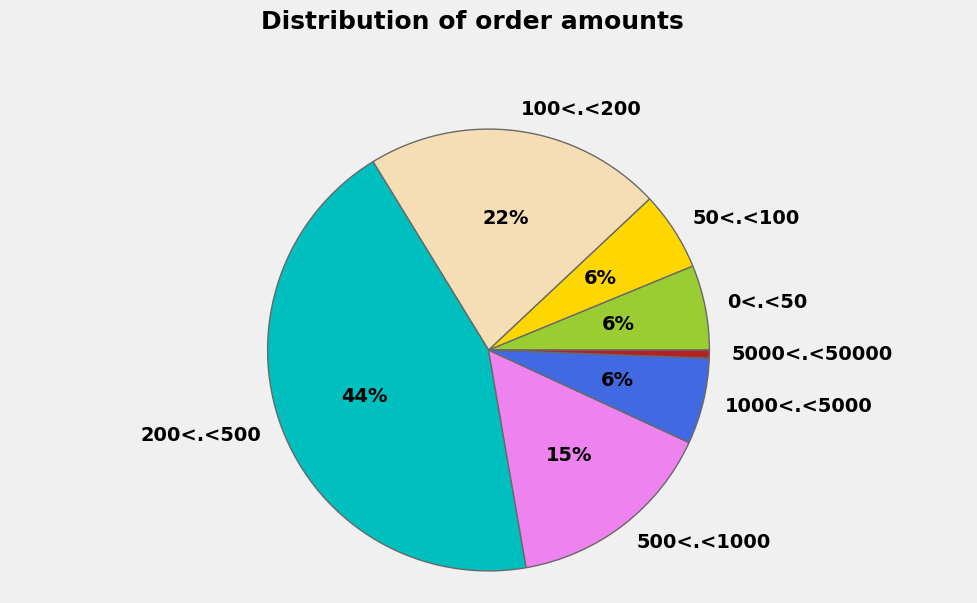

In [32]:
price_range = [0, 50, 100, 200, 500, 1000, 5000, 50000]

count_price = []

for i, price in enumerate(price_range):
    if i == 0: continue
    val = basket_price[(basket_price['Basket Price'] < price) &
                       (basket_price['Basket Price'] > price_range[i-1])]['Basket Price'].count()
    count_price.append(val)



# Representation of the number of purchases / amount
plt.rc('font', weight='bold')
f, ax = plt.subplots(figsize=(11, 6))
colors = ['yellowgreen', 'gold', 'wheat', 'c', 'violet', 'royalblue','firebrick']
labels = [ '{}<.<{}'.format(price_range[i-1], s) for i,s in enumerate(price_range) if i != 0]
sizes  = count_price
explode = [0.0 if sizes[i] < 100 else 0.0 for i in range(len(sizes))]
ax.pie(sizes, explode = explode, labels=labels, colors = colors,
       autopct = lambda x:'{:1.0f}%'.format(x) if x > 1 else '',
       shadow = False, startangle=0)
ax.axis('equal')
f.text(0.5, 1.01, "Distribution of order amounts", ha='center', fontsize = 18);

In [33]:
from datetime import timedelta

df_cleaned['TotalAmount'] = (df_cleaned['Quantity'] - df_cleaned['QuantityCanceled']) * df_cleaned['UnitPrice']

snapshot_date = df_cleaned['InvoiceDate'].max() + timedelta(days=1)

rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Ngày gần nhất
    'InvoiceNo': 'nunique',                                 # Frequency: Số đơn hàng duy nhất
    'TotalAmount': 'sum'                                    # Monetary: Tổng số tiền chi trả
})


rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

In [34]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,0.00
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [35]:
len(rfm)

4339

In [36]:
is_noun = lambda pos: pos[:2] == 'NN'

def keywords_inventory(dataframe, colonne = 'Description'):
    stemmer = nltk.stem.SnowballStemmer("english")  # NLTK stemmer (Snowball stemmer)
    keywords_roots  = dict()  # collect the words / root
    keywords_select = dict()  # association: root <-> keyword
    category_keys   = []
    count_keywords  = dict()
    icount = 0
    for s in dataframe[colonne]:
        if pd.isnull(s): continue
        lines = s.lower()
        tokenized = nltk.word_tokenize(lines)
        nouns = [word for (word, pos) in nltk.pos_tag(tokenized) if is_noun(pos)]

        for t in nouns:
            t = t.lower() ; racine = stemmer.stem(t)
            if racine in keywords_roots:
                keywords_roots[racine].add(t)
                count_keywords[racine] += 1
            else:
                keywords_roots[racine] = {t}
                count_keywords[racine] = 1

    for s in keywords_roots.keys():
        if len(keywords_roots[s]) > 1:
            min_length = 1000
            for k in keywords_roots[s]:
                if len(k) < min_length:
                    clef = k ; min_length = len(k)
            category_keys.append(clef)
            keywords_select[s] = clef
        else:
            category_keys.append(list(keywords_roots[s])[0])
            keywords_select[s] = list(keywords_roots[s])[0]


    print("No. of keywords in variable '{}': {}".format(colonne,len(category_keys)))
    return category_keys, keywords_roots, keywords_select, count_keywords

In [37]:
df_products = pd.DataFrame(data_set['Description'].unique()).rename(columns = {0:'Description'})

In [38]:
len(df_products)

3896

In [39]:
import nltk
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/znoy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [40]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
keywords, keywords_roots, keywords_select, count_keywords = keywords_inventory(df_products)

[nltk_data] Downloading package punkt_tab to /home/znoy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/znoy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


No. of keywords in variable 'Description': 1483


In [41]:
list_products = []
for k,v in count_keywords.items():
    list_products.append([keywords_select[k],v])
list_products.sort(key = lambda x:x[1], reverse = True)

In [42]:
len(list_products)

1483

In [43]:
list_products

[['heart', 267],
 ['vintage', 211],
 ['set', 206],
 ['pink', 189],
 ['bag', 165],
 ['box', 155],
 ['glass', 149],
 ['christmas', 137],
 ['design', 128],
 ['candle', 121],
 ['holder', 120],
 ['flower', 120],
 ['decoration', 109],
 ['metal', 99],
 ['retrospot', 90],
 ['card', 90],
 ['necklac', 85],
 ['paper', 84],
 ['blue', 80],
 ['art', 75],
 ['silver', 72],
 ['cake', 70],
 ['polkadot', 68],
 ['cover', 68],
 ['mug', 66],
 ['tin', 66],
 ['wrap', 65],
 ['sign', 64],
 ['pack', 61],
 ['egg', 61],
 ['bracelet', 61],
 ['star', 59],
 ['bowl', 57],
 ['mini', 56],
 ['tea', 55],
 ['garden', 55],
 ['wall', 55],
 ['ivory', 54],
 ['cushion', 54],
 ['frame', 52],
 ['mirror', 50],
 ['cream', 49],
 ['home', 49],
 ['gift', 49],
 ['earrings', 49],
 ['ring', 46],
 ['bird', 45],
 ['bottle', 44],
 ['clock', 44],
 ['paisley', 42],
 ['letter', 42],
 ['party', 42],
 ['charm', 41],
 ['wood', 40],
 ['ribbon', 40],
 ['jar', 39],
 ['garland', 39],
 ['hook', 39],
 ['gold', 39],
 ['easter', 39],
 ['bead', 38],
 ['dr

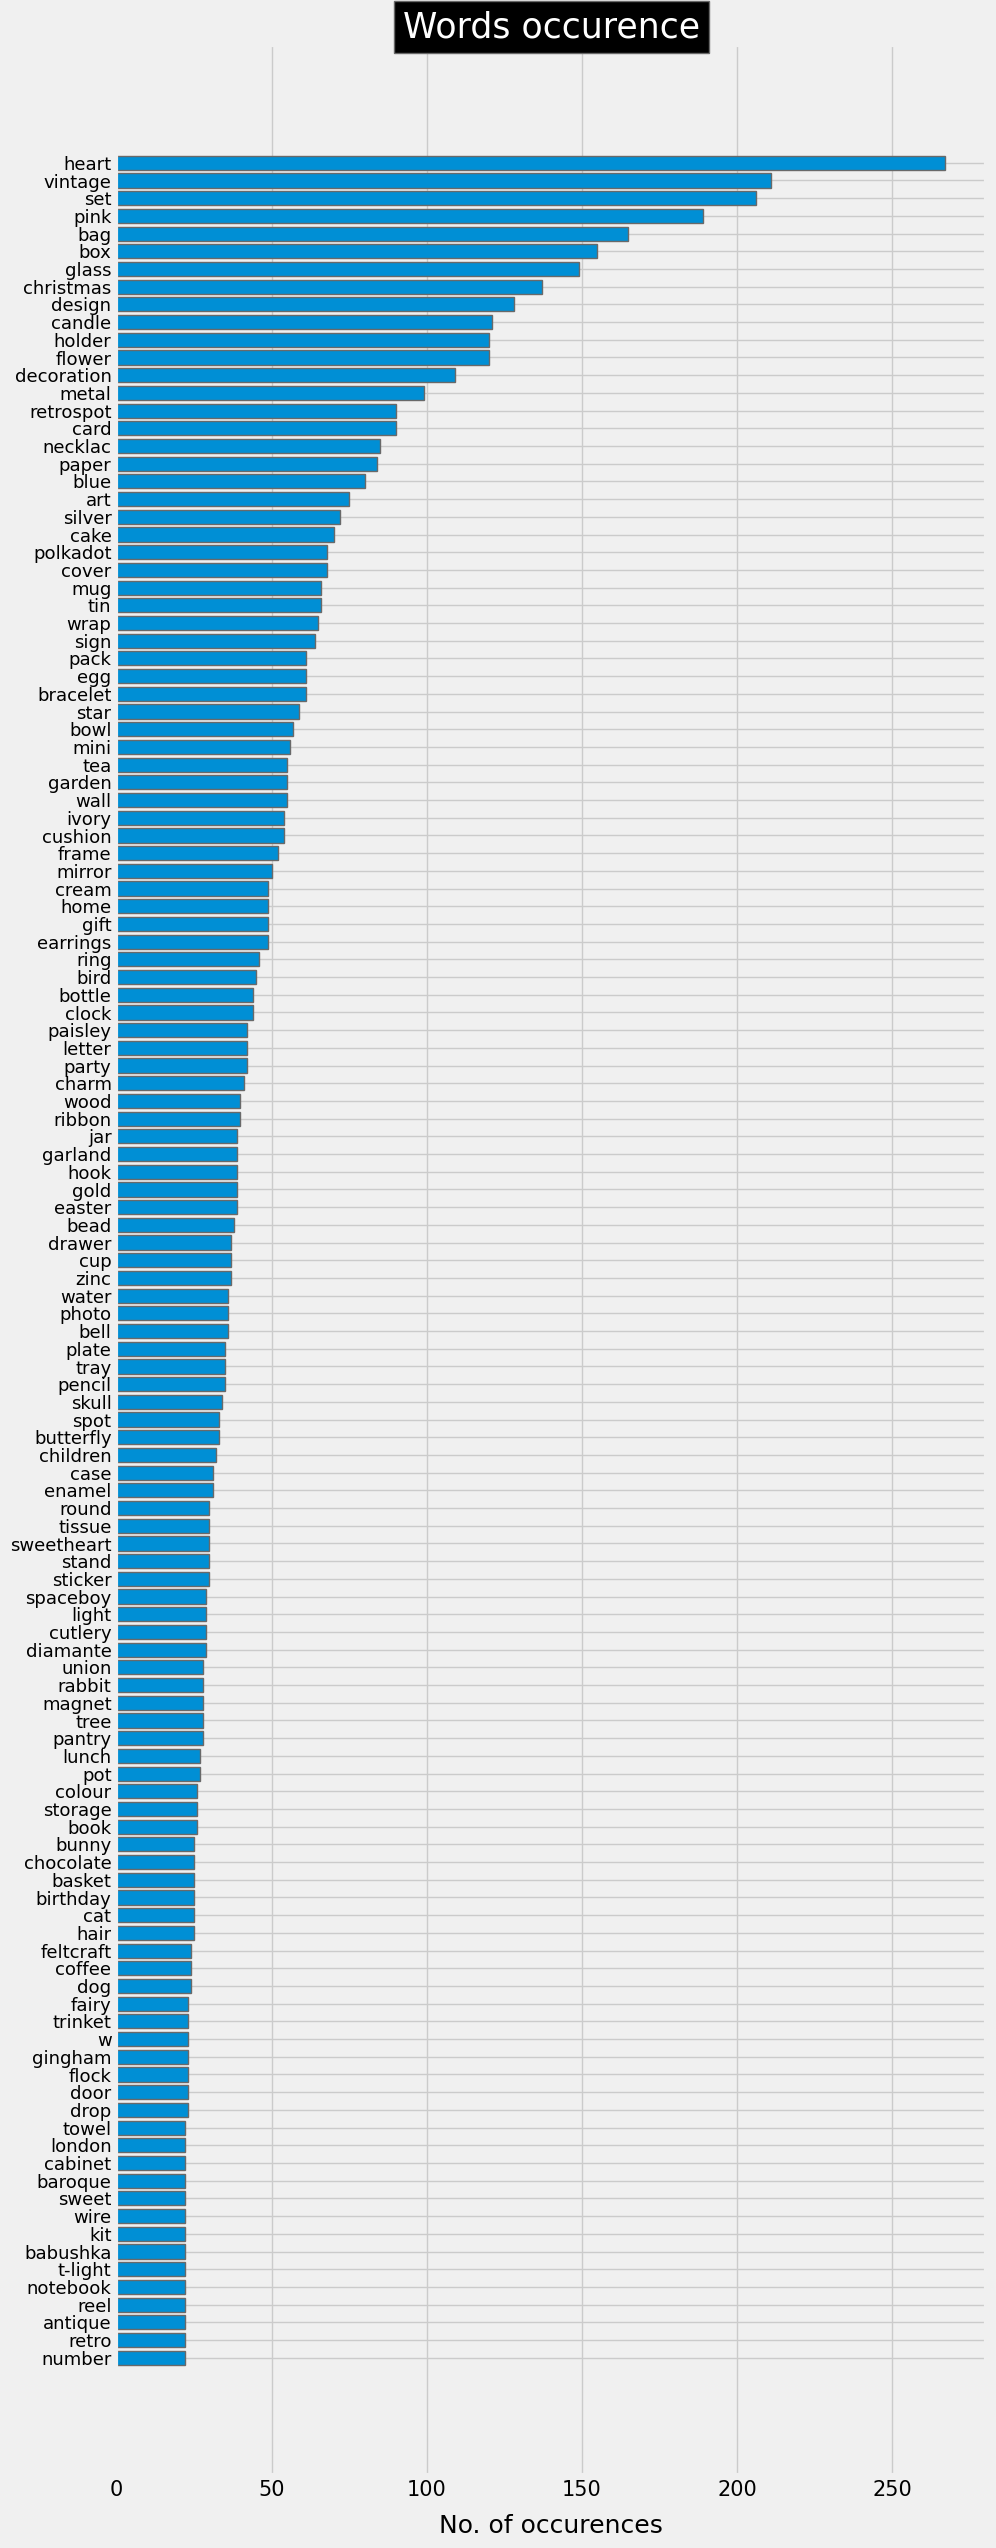

In [44]:
liste = sorted(list_products, key = lambda x:x[1], reverse = True)


plt.rc('font', weight='normal')
fig, ax = plt.subplots(figsize=(10, 30))
y_axis = [i[1] for i in liste[:125]]
x_axis = [k for k,i in enumerate(liste[:125])]
x_label = [i[0] for i in liste[:125]]
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 13)
plt.yticks(x_axis, x_label)
plt.xlabel("No. of occurences", fontsize = 18, labelpad = 10)
ax.barh(x_axis, y_axis, align = 'center')
ax = plt.gca()
ax.invert_yaxis()


plt.title("Words occurence",bbox={'facecolor':'k', 'pad':5}, color='w',fontsize = 25)
plt.show()

In [45]:
list_products = []


# Loop through the count_keywords and check the different conditions
for k,v in count_keywords.items():
    word = keywords_select[k]
    if word in ['pink', 'blue', 'tag', 'green', 'orange']: continue
    if len(word) < 3 or v < 13: continue
    if ('+' in word) or ('/' in word): continue
    list_products.append([word, v])
    

# list most kept words
list_products.sort(key = lambda x:x[1], reverse = True)
print('words kept:', len(list_products))

words kept: 193


In [46]:


liste_produits = df_cleaned['Description'].unique()
X = pd.DataFrame()
for key, occurence in list_products:
    X.loc[:, key] = list(map(lambda x:int(key.upper() in x), liste_produits))

In [47]:
threshold = [0, 1, 2, 3, 5, 10]
label_col = []

for i in range(len(threshold)):
    if i == len(threshold)-1:
        col = '.>{}'.format(threshold[i])
    else:
        col = '{}<.<{}'.format(threshold[i],threshold[i+1])
    label_col.append(col)
    X.loc[:, col] = 0

for i, prod in enumerate(liste_produits):
    prix = df_cleaned[df_cleaned['Description'] == prod]['UnitPrice'].mean()
    j = 0
    while prix > threshold[j]:
        j+=1
        if j == len(threshold): break
    X.loc[i, label_col[j-1]] = 1

In [48]:
print("{:<8} {:<20} \n".format('range', 'no. products') + 20*'-')

for i in range(len(threshold)):
    if i == len(threshold)-1:
        col = '.>{}'.format(threshold[i])
    else:
        col = '{}<.<{}'.format(threshold[i],threshold[i+1])
    print("{:<10}  {:<20}".format(col, X.loc[:, col].sum()))

range    no. products         
--------------------
0<.<1       964                 
1<.<2       1009                
2<.<3       673                 
3<.<5       606                 
5<.<10      470                 
.>10        156                 


In [49]:
matrix = X.to_numpy()

for n_clusters in range(3,10):
    kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=30)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

For n_clusters = 3 The average silhouette_score is : 0.10158702596012364
For n_clusters = 4 The average silhouette_score is : 0.1268004588393788
For n_clusters = 5 The average silhouette_score is : 0.14679607861398997
For n_clusters = 6 The average silhouette_score is : 0.14509988406712557
For n_clusters = 7 The average silhouette_score is : 0.14929259873918427
For n_clusters = 8 The average silhouette_score is : 0.14871647887391146
For n_clusters = 9 The average silhouette_score is : 0.1485856445291014


In [50]:
n_clusters = 5
silhouette_avg = -1
while silhouette_avg < 0.145:
    kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=30)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

For n_clusters = 5 The average silhouette_score is : 0.14740815062347604


In [51]:
clusters

array([0, 4, 4, ..., 1, 0, 0], shape=(3878,), dtype=int32)

In [52]:
pd.Series(clusters).value_counts()

2    1009
1     964
0     673
3     626
4     606
Name: count, dtype: int64

In [53]:
pca = PCA(n_components=50)
matrix_9D = pca.fit_transform(matrix)
mat = pd.DataFrame(matrix_9D)
mat['cluster'] = pd.Series(clusters)

In [54]:
def graph_component_silhouette(n_clusters, lim_x, mat_size, sample_silhouette_values, clusters):
    plt.rcParams["patch.force_edgecolor"] = True
    plt.style.use('fivethirtyeight')
    mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)
    
    
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(8, 8)
    ax1.set_xlim([lim_x[0], lim_x[1]])
    ax1.set_ylim([0, mat_size + (n_clusters + 1) * 10])
    y_lower = 10
    for i in range(n_clusters):
        
        
        
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        cmap = cm.get_cmap("Spectral")
        color = cmap(float(i) / n_clusters)        
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                           facecolor=color, edgecolor=color, alpha=0.8)
        
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.03, y_lower + 0.5 * size_cluster_i, str(i), color = 'red', fontweight = 'bold',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.3'))
           
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10

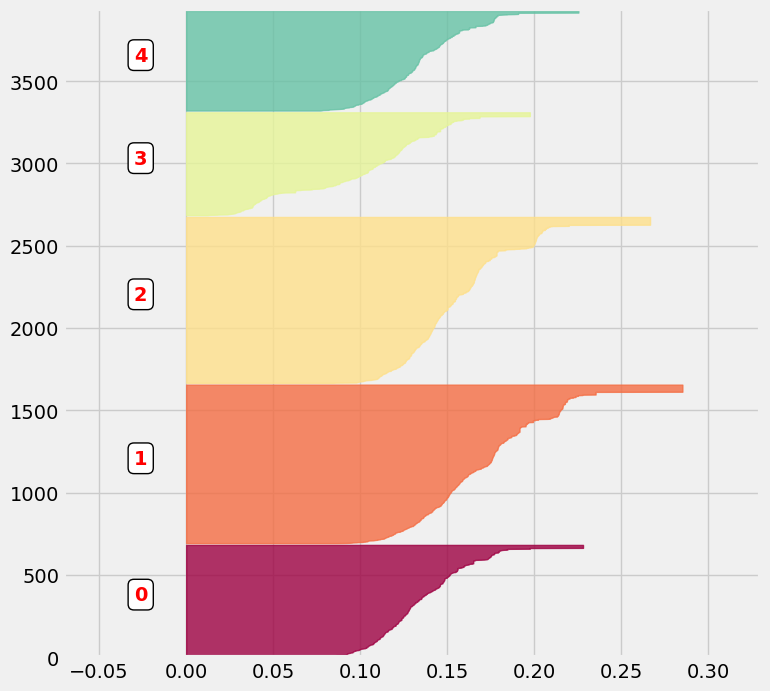

In [55]:
# define individual silouhette scores
sample_silhouette_values = silhouette_samples(matrix, clusters)

# and do the graph
graph_component_silhouette(n_clusters, [-0.07, 0.33], len(X), sample_silhouette_values, clusters)

In [56]:
liste = pd.DataFrame(liste_produits)
liste_words = [word for (word, occurence) in list_products]

occurence = [dict() for _ in range(n_clusters)]

for i in range(n_clusters):
    liste_cluster = liste.loc[clusters == i]
    for word in liste_words:
        if word in ['art', 'set', 'heart', 'pink', 'blue', 'tag']: continue
        occurence[i][word] = sum(liste_cluster.loc[:, 0].str.contains(word.upper()))

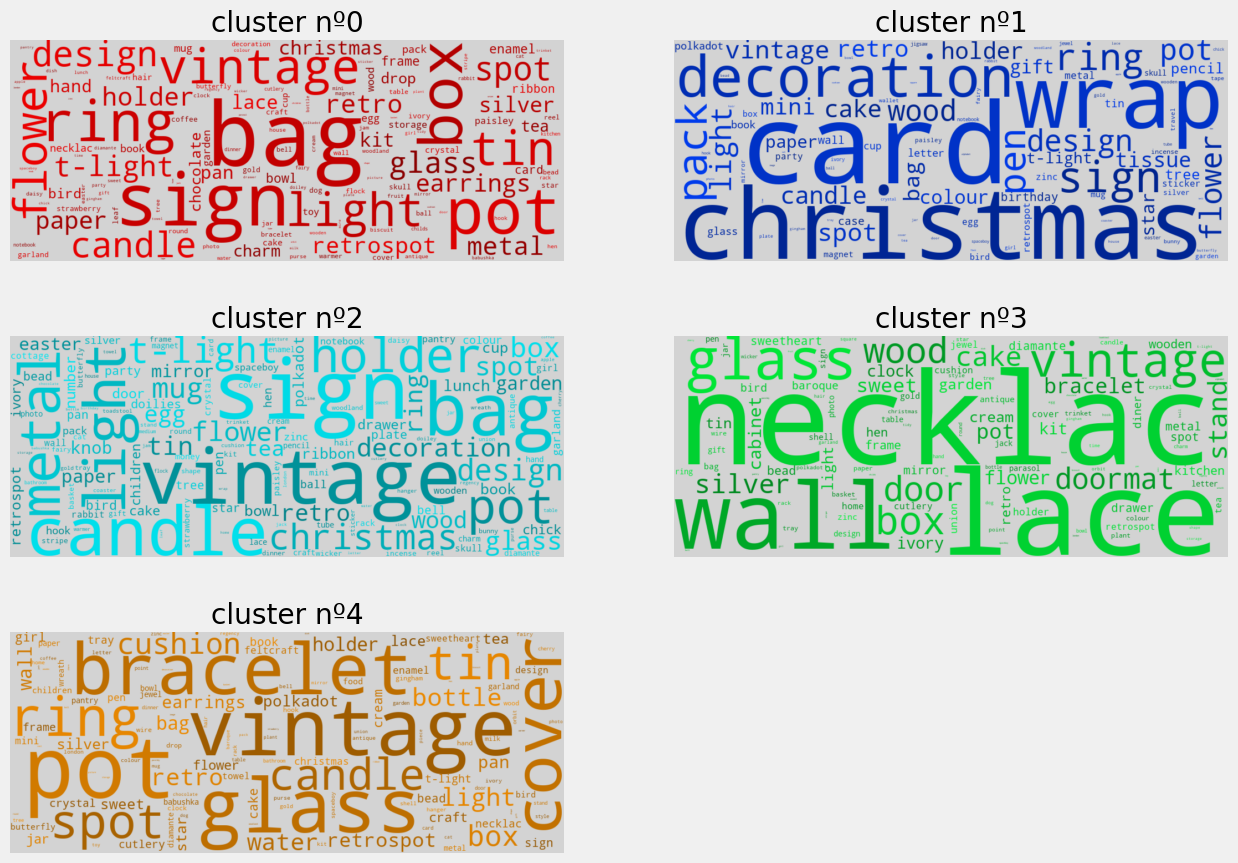

In [57]:
def random_color_func(word=None, font_size=None, position=None,
                      orientation=None, font_path=None, random_state=None):
    h = int(360.0 * tone / 255.0)
    s = int(100.0 * 255.0 / 255.0)
    l = int(100.0 * float(random_state.randint(70, 120)) / 255.0)
    return "hsl({}, {}%, {}%)".format(h, s, l)

#
def make_wordcloud(liste, increment):
    ax1 = fig.add_subplot(4,2,increment)
    words = dict()
    trunc_occurences = liste[0:150]
    for s in trunc_occurences:
        words[s[0]] = s[1]
        
    #
    wordcloud = WordCloud(width=1000,height=400, background_color='lightgrey', 
                          max_words=1628,relative_scaling=1,
                          color_func = random_color_func,
                          normalize_plurals=False)
    wordcloud.generate_from_frequencies(words)
    ax1.imshow(wordcloud, interpolation="bilinear")
    ax1.axis('off')
    plt.title('cluster nº{}'.format(increment-1))
    
#
fig = plt.figure(1, figsize=(14,14))
color = [0, 160, 130, 95, 280, 40, 330, 110, 25]
for i in range(n_clusters):
    list_cluster_occurences = occurence[i]

    tone = color[i] # define the color of the words
    liste = []
    for key, value in list_cluster_occurences.items():
        liste.append([key, value])
    liste.sort(key = lambda x:x[1], reverse = True)
    make_wordcloud(liste, i+1) 

In [58]:
pca = PCA()
pca.fit(matrix)
pca_samples = pca.transform(matrix)

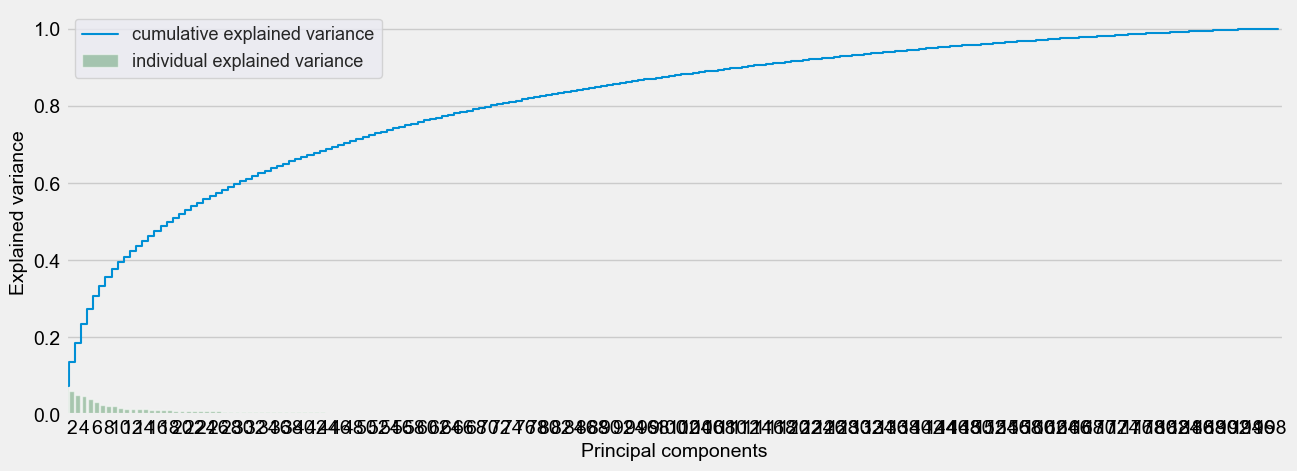

In [59]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.set(font_scale=1)
plt.step(range(pca.n_components_), pca.explained_variance_ratio_.cumsum(), where='mid',
         label='cumulative explained variance')

sns.barplot(x=np.arange(1, pca.n_components_+1), y=pca.explained_variance_ratio_, alpha=0.5, color = 'g',
            label='individual explained variance')

plt.xlim(0, pca.n_components_)


ax.set_xticklabels([s if int(s.get_text())%2 == 0 else '' for s in ax.get_xticklabels()])

plt.ylabel('Explained variance', fontsize = 14)
plt.xlabel('Principal components', fontsize = 14)
plt.legend(loc='upper left', fontsize = 13);

In [60]:
pca = PCA(n_components=50)
matrix_9D = pca.fit_transform(matrix)
mat = pd.DataFrame(matrix_9D)
mat['cluster'] = pd.Series(clusters)

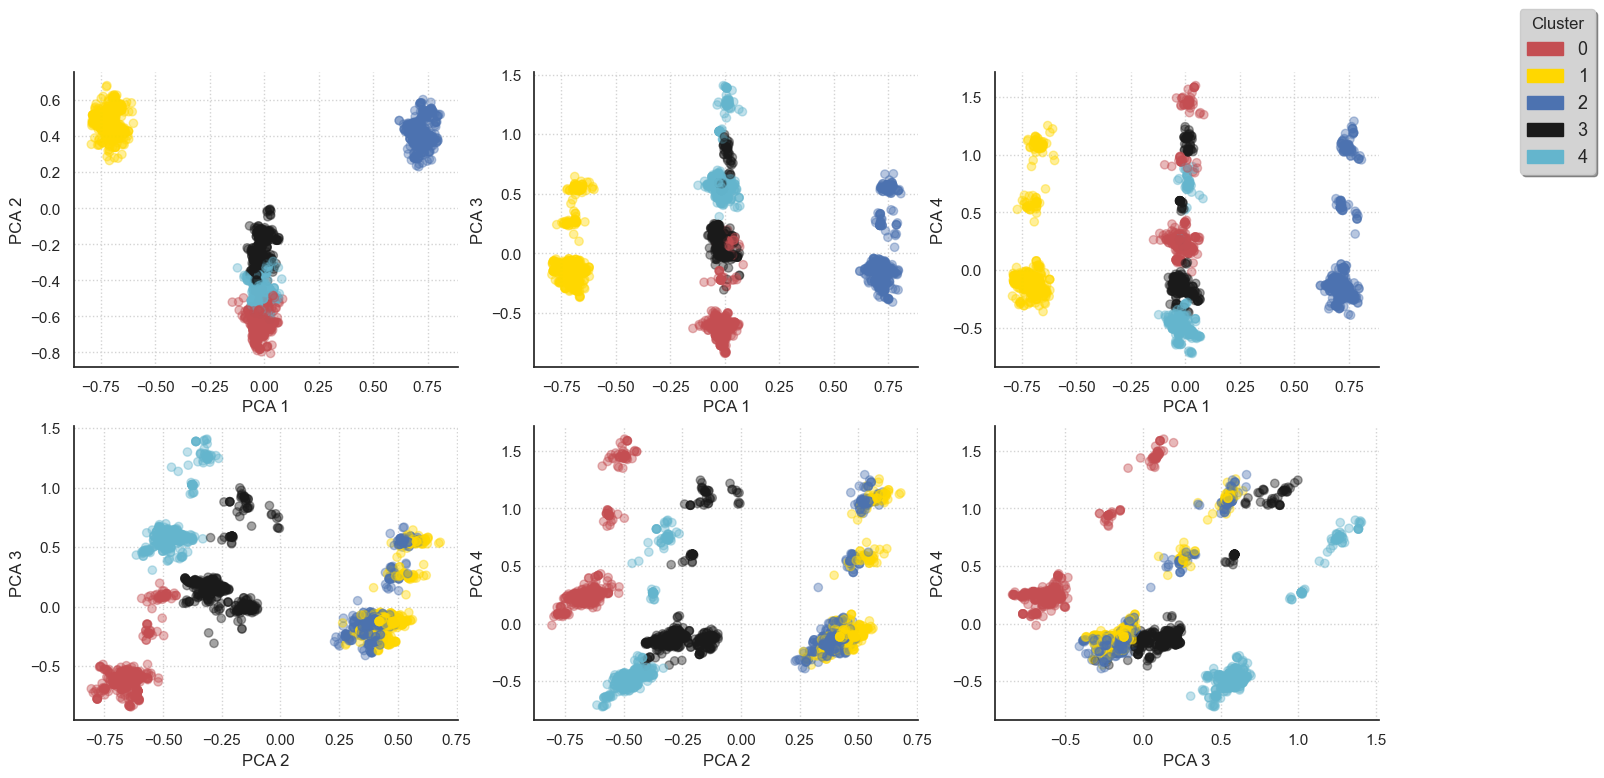

In [61]:
import matplotlib.patches as mpatches

sns.set_style("white")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2.5})

LABEL_COLOR_MAP = {0:'r', 1:'gold', 2:'b', 3:'k', 4:'c', 5:'g'}
label_color = [LABEL_COLOR_MAP[l] for l in mat['cluster']]

fig = plt.figure(figsize = (15,8))
increment = 0
for ix in range(4):
    for iy in range(ix+1, 4):    
        increment += 1
        ax = fig.add_subplot(2,3,increment)
        ax.scatter(mat[ix], mat[iy], c= label_color, alpha=0.4) 
        plt.ylabel('PCA {}'.format(iy+1), fontsize = 12)
        plt.xlabel('PCA {}'.format(ix+1), fontsize = 12)
        ax.yaxis.grid(color='lightgray', linestyle=':')
        ax.xaxis.grid(color='lightgray', linestyle=':')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
        if increment == 9: break
    if increment == 9: break
        

# I set the legend: abreviation -> airline name
comp_handler = []
for i in range(5):
    comp_handler.append(mpatches.Patch(color = LABEL_COLOR_MAP[i], label = i))

plt.legend(handles=comp_handler, bbox_to_anchor=(1.1, 0.97), 
           title='Cluster', facecolor = 'lightgrey',
           shadow = True, frameon = True, framealpha = 1,
           fontsize = 13, bbox_transform = plt.gcf().transFigure)

plt.show()

In [62]:
corresp = dict()
for key, val in zip (liste_produits, clusters):
    corresp[key] = val 

df_cleaned['categ_product'] = df_cleaned.loc[:, 'Description'].map(corresp)

In [63]:
for i in range(5):
    col = 'categ_{}'.format(i)        
    df_temp = df_cleaned[df_cleaned['categ_product'] == i]
    price_temp = df_temp['UnitPrice'] * (df_temp['Quantity'] - df_temp['QuantityCanceled'])
    price_temp = price_temp.apply(lambda x:x if x > 0 else 0)
    df_cleaned.loc[:, col] = price_temp
    df_cleaned[col].fillna(0, inplace = True)
    

df_cleaned[['InvoiceNo', 'Description', 'categ_product', 'categ_0', 'categ_1', 'categ_2', 'categ_3','categ_4']][:5]

,InvoiceNo,Description,categ_product,categ_0,categ_1,categ_2,categ_3,categ_4
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,0,15.3,0.0,0.0,0.0,0.00
1,536365,WHITE METAL LANTERN,4,0.0,0.0,0.0,0.0,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,4,0.0,0.0,0.0,0.0,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,4,0.0,0.0,0.0,0.0,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,4,0.0,0.0,0.0,0.0,20.34


In [64]:
# sum of purchases / user & order
temp_total_price = df_cleaned.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['TotalPrice'].sum()
basket_price = temp_total_price.rename(columns = {'TotalPrice':'Basket Price'})

# percentage of the order price / product category
for i in range(5):
    col = 'categ_{}'.format(i)
    temp_category_sum = df_cleaned.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)[col].sum()
    # Merge the category sum back into basket_price
    basket_price = pd.merge(basket_price, temp_category_sum, on=['CustomerID', 'InvoiceNo'], how='left')

# date of the order
df_cleaned['InvoiceDate_int'] = df_cleaned['InvoiceDate'].astype('int64')
temp_date = df_cleaned.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate_int'].mean()
df_cleaned.drop('InvoiceDate_int', axis = 1, inplace = True)
# Merge the InvoiceDate back into basket_price
basket_price = pd.merge(basket_price, temp_date.rename(columns={'InvoiceDate_int': 'InvoiceDate'}), on=['CustomerID', 'InvoiceNo'], how='left')
basket_price['InvoiceDate'] = pd.to_datetime(basket_price['InvoiceDate']) # Convert to datetime after merge

# selection of significant entries:
basket_price = basket_price[basket_price['Basket Price'] > 0]
basket_price.sort_values('CustomerID', ascending = True)[:5]

,CustomerID,InvoiceNo,Basket Price,categ_0,categ_1,categ_2,categ_3,categ_4,InvoiceDate
1,12347,537626,711.79,83.40,23.40,187.2,124.44,293.35,2010-12-07 14:57:00.000000000
2,12347,542237,475.39,53.10,84.34,130.5,38.25,169.20,2011-01-26 14:29:59.999999744
3,12347,549222,636.25,71.10,81.00,330.9,38.25,115.00,2011-04-07 10:43:00.000000000
4,12347,556201,382.52,78.06,41.40,74.4,19.90,168.76,2011-06-09 13:01:00.000000000
5,12347,562032,584.91,119.70,61.30,109.7,136.05,158.16,2011-08-02 08:48:00.000000000


# Chia DATA SET THành 2 khoảng thời gian để chạy thử model so  với thực tế 

In [65]:
print(basket_price['InvoiceDate'].min(), '->',  basket_price['InvoiceDate'].max())

2010-12-01 08:26:00 -> 2011-12-09 12:50:00


In [66]:
set_training = basket_price[basket_price['InvoiceDate'] < pd.to_datetime('2011-10-01')]
set_test    = basket_price[basket_price['InvoiceDate'] >= pd.to_datetime('2011-10-01')]
basket_price = set_training.copy(deep = True)

In [67]:
# number of visits and stats on the basket amount / users
transactions_per_user=basket_price.groupby(by=['CustomerID'])['Basket Price'].agg(['count','min','max','mean','sum'])
for i in range(5):
    col = 'categ_{}'.format(i)
    transactions_per_user.loc[:,col] = basket_price.groupby(by=['CustomerID'])[col].sum() /\
                                            transactions_per_user['sum']*100

transactions_per_user.reset_index(drop = False, inplace = True)
basket_price.groupby(by=['CustomerID'])['categ_0'].sum()
transactions_per_user.sort_values('CustomerID', ascending = True)[:5]

,CustomerID,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4
0,12347,5,382.52,711.79,558.172000,2790.86,14.524555,10.442659,29.836681,12.787815,32.408290
1,12348,4,227.44,892.80,449.310000,1797.24,0.000000,38.016069,41.953217,20.030714,0.000000
2,12350,1,334.40,334.40,334.400000,334.40,27.900718,11.692584,48.444976,11.961722,0.000000
3,12352,6,144.35,840.30,345.663333,2073.98,3.370331,0.491808,12.892120,67.534402,15.711338
4,12353,1,89.00,89.00,89.000000,89.00,19.887640,0.000000,13.033708,67.078652,0.000000


In [68]:
last_date = basket_price['InvoiceDate'].max().date()

first_registration = pd.DataFrame(basket_price.groupby(by=['CustomerID'])['InvoiceDate'].min())
last_purchase      = pd.DataFrame(basket_price.groupby(by=['CustomerID'])['InvoiceDate'].max())

test  = first_registration.applymap(lambda x:(last_date - x.date()).days)
test2 = last_purchase.applymap(lambda x:(last_date - x.date()).days)

transactions_per_user.loc[:, 'LastPurchase'] = test2.reset_index(drop = False)['InvoiceDate']
transactions_per_user.loc[:, 'FirstPurchase'] = test.reset_index(drop = False)['InvoiceDate']

transactions_per_user[:5]

,CustomerID,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4,LastPurchase,FirstPurchase
0,12347,5,382.52,711.79,558.172000,2790.86,14.524555,10.442659,29.836681,12.787815,32.408290,59,297
1,12348,4,227.44,892.80,449.310000,1797.24,0.000000,38.016069,41.953217,20.030714,0.000000,5,288
2,12350,1,334.40,334.40,334.400000,334.40,27.900718,11.692584,48.444976,11.961722,0.000000,240,240
3,12352,6,144.35,840.30,345.663333,2073.98,3.370331,0.491808,12.892120,67.534402,15.711338,2,226
4,12353,1,89.00,89.00,89.000000,89.00,19.887640,0.000000,13.033708,67.078652,0.000000,134,134


In [69]:
len(transactions_per_user)

3608

### Khách hàng mua một lần


In [70]:
n1_check = transactions_per_user[transactions_per_user['count'] == 1].shape[0]
n1_check

1445

### Tổng số khách hàng

In [71]:
n1_check = transactions_per_user.shape[0]
n1_check

3608

## Data Encoding

In [72]:
list_cols = ['count','min','max','mean','categ_0','categ_1','categ_2','categ_3','categ_4']

#
selected_customers = transactions_per_user.copy(deep = True)
matrix = selected_customers[list_cols].to_numpy()

In [73]:
matrix

array([[  5.        , 382.52      , 711.79      , ...,  29.83668117,
         12.78781451,  32.40828992],
       [  4.        , 227.44      , 892.8       , ...,  41.95321716,
         20.03071376,   0.        ],
       [  1.        , 334.4       , 334.4       , ...,  48.44497608,
         11.96172249,   0.        ],
       ...,
       [  1.        ,  98.76      ,  98.76      , ...,  23.2381531 ,
         25.82017011,  13.66950182],
       [ 10.        ,   2.5       , 192.8       , ...,  36.80520413,
          2.79252505,   8.29016498],
       [  1.        , 765.28      , 765.28      , ...,  70.68001254,
          4.44281831,   1.9600669 ]], shape=(3608, 9))

In [74]:
scaler = StandardScaler()
scaler.fit(matrix)
print('variables mean values: \n' + 90*'-' + '\n' , scaler.mean_)
scaled_matrix = scaler.transform(matrix)

variables mean values: 
------------------------------------------------------------------------------------------
 [  3.62305987 259.93189634 556.26687999 377.06036244  21.19884856
  13.98907929  25.22916919  23.21847344  16.37327913]


In [75]:
scaled_matrix

array([[ 0.22682222,  0.37730645,  0.13954061, ...,  0.2634011 ,
        -0.49675773,  1.08592146],
       [ 0.06209304, -0.10000483,  0.30194891, ...,  0.95607623,
        -0.15181632, -1.10882963],
       [-0.4320945 ,  0.22920083, -0.19906647, ...,  1.32719549,
        -0.53610017, -1.10882963],
       ...,
       [-0.4320945 , -0.49606115, -0.41049066, ..., -0.11382191,
         0.1239052 , -0.18310495],
       [ 1.05046812, -0.79233393, -0.32611479, ...,  0.6617759 ,
        -0.97278108, -0.54740388],
       [-0.4320945 ,  1.55538011,  0.18753365, ...,  2.59832254,
        -0.89418624, -0.97609017]], shape=(3608, 9))

In [76]:
pca = PCA()
pca.fit(scaled_matrix)
pca_samples = pca.transform(scaled_matrix)

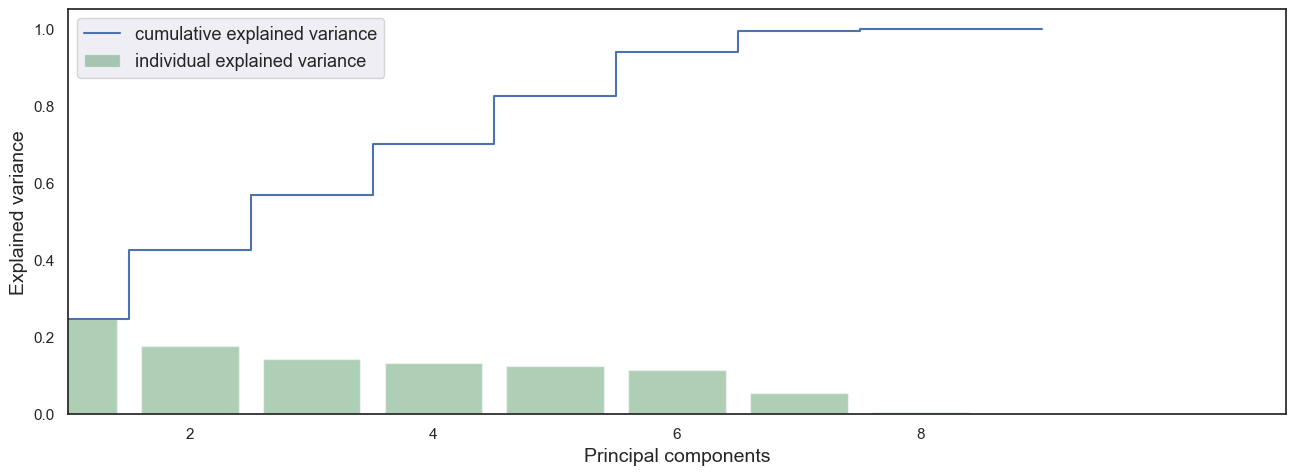

In [77]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.set(font_scale=1)
plt.step(range(matrix.shape[1]), pca.explained_variance_ratio_.cumsum(), where='mid',
         label='cumulative explained variance')
sns.barplot(x=np.arange(1,matrix.shape[1]+1), y=pca.explained_variance_ratio_, alpha=0.5, color = 'g',
            label='individual explained variance')
plt.xlim(0, 10)

ax.set_xticklabels([s if int(s.get_text())%2 == 0 else '' for s in ax.get_xticklabels()])

plt.ylabel('Explained variance', fontsize = 14)
plt.xlabel('Principal components', fontsize = 14)
plt.legend(loc='best', fontsize = 13);

In [78]:
for i in range(2,12):
    kmeans = KMeans(init='k-means++', n_clusters = i, n_init=100)
    kmeans.fit(scaled_matrix)
    clusters_clients = kmeans.predict(scaled_matrix)
    silhouette_avg = silhouette_score(scaled_matrix, clusters_clients)
    print('silhouette score of {}: {:<.3f}'.format(i,silhouette_avg))
    display(pd.Series(clusters_clients).value_counts().to_frame(name='no. of customers').T)

silhouette score of 2: 0.645


,1,0
no. of customers,3534,74


silhouette score of 3: 0.159


,0,2,1
no. of customers,2137,1398,73


silhouette score of 4: 0.152


...

,4,6,3,1,0,2,8,7,5
no. of customers,1547,537,470,351,335,236,103,22,7


silhouette score of 10: 0.213


,0,5,8,1,4,7,2,9,6,3
no. of customers,1507,531,468,319,307,233,199,21,12,11


silhouette score of 11: 0.216


,5,2,1,9,8,0,10,3,7,6,4
no. of customers,1427,496,463,289,286,231,193,188,15,13,7


In [79]:
n_clusters = 11
kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=100)
kmeans.fit(scaled_matrix)
clusters_clients = kmeans.predict(scaled_matrix)
silhouette_avg = silhouette_score(scaled_matrix, clusters_clients)
print('silhouette score: {:<.3f}'.format(silhouette_avg))

silhouette score: 0.217


In [80]:
pd.Series(clusters_clients).value_counts().to_frame(name='no. of customers').T

,9,2,1,5,8,0,7,10,6,3,4
no. of customers,1443,509,462,289,286,230,199,151,24,8,7


In [81]:
pca = PCA(n_components=6)
matrix_3D = pca.fit_transform(scaled_matrix)
mat = pd.DataFrame(matrix_3D)
mat['cluster'] = pd.Series(clusters_clients)

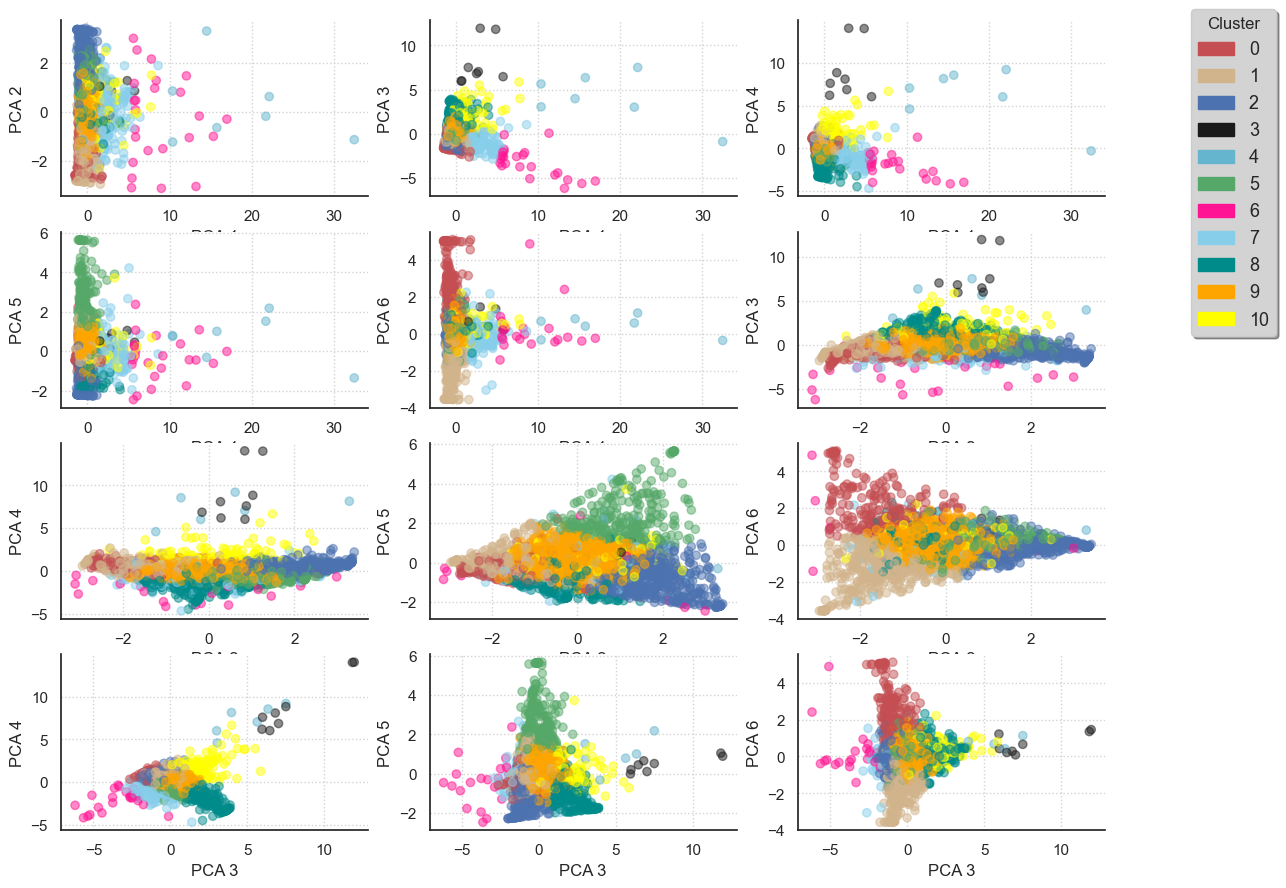

In [82]:
import matplotlib.patches as mpatches

sns.set_style("white")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2.5})

LABEL_COLOR_MAP = {0:'r', 1:'tan', 2:'b', 3:'k', 4:'c', 5:'g', 6:'deeppink', 7:'skyblue', 8:'darkcyan', 9:'orange',
                   10:'yellow', 11:'tomato', 12:'seagreen'}
label_color = [LABEL_COLOR_MAP[l] for l in mat['cluster']]

fig = plt.figure(figsize = (12,10))
increment = 0
for ix in range(6):
    for iy in range(ix+1, 6):   
        increment += 1
        ax = fig.add_subplot(4,3,increment)
        ax.scatter(mat[ix], mat[iy], c= label_color, alpha=0.5) 
        plt.ylabel('PCA {}'.format(iy+1), fontsize = 12)
        plt.xlabel('PCA {}'.format(ix+1), fontsize = 12)
        ax.yaxis.grid(color='lightgray', linestyle=':')
        ax.xaxis.grid(color='lightgray', linestyle=':')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
        if increment == 12: break
    if increment == 12: break
        
# I set the legend: abreviation -> airline name
comp_handler = []
for i in range(n_clusters):
    comp_handler.append(mpatches.Patch(color = LABEL_COLOR_MAP[i], label = i))

plt.legend(handles=comp_handler, bbox_to_anchor=(1.1, 0.9), 
           title='Cluster', facecolor = 'lightgrey',
           shadow = True, frameon = True, framealpha = 1,
           fontsize = 13, bbox_transform = plt.gcf().transFigure)

plt.tight_layout()

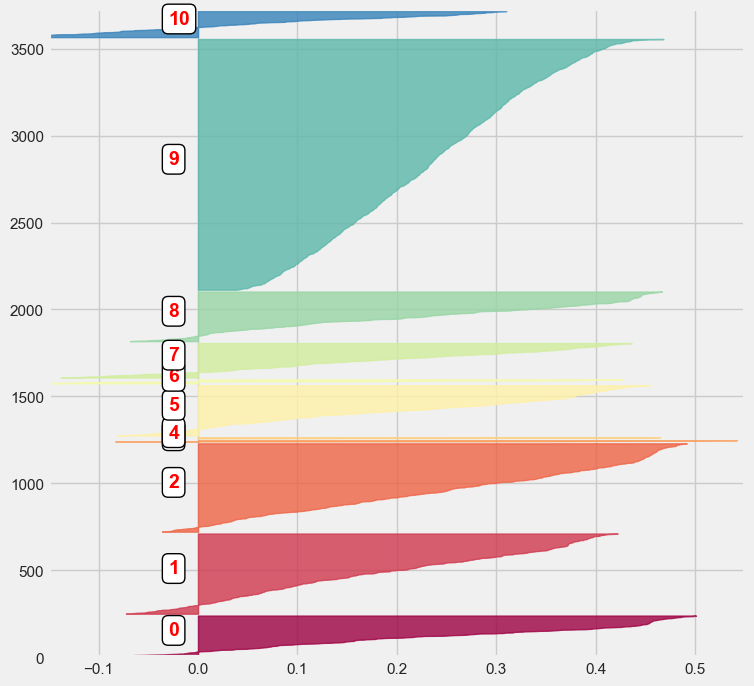

In [83]:

sample_silhouette_values = silhouette_samples(scaled_matrix, clusters_clients)

# define individual silouhette scores
sample_silhouette_values = silhouette_samples(scaled_matrix, clusters_clients)

# and do the graph
graph_component_silhouette(n_clusters, [-0.15, 0.55], len(scaled_matrix), sample_silhouette_values, clusters_clients)

In [84]:
selected_customers.loc[:, 'cluster'] = clusters_clients

In [85]:
merged_df = pd.DataFrame()
for i in range(n_clusters):
    test = pd.DataFrame(selected_customers[selected_customers['cluster'] == i].mean(numeric_only=True))
    test = test.T.set_index('cluster', drop = True)
    test['size'] = selected_customers[selected_customers['cluster'] == i].shape[0]
    merged_df = pd.concat([merged_df, test])


print('number of customers:', merged_df['size'].sum())

merged_df = merged_df.sort_values('sum')

number of customers: 3608


In [86]:
merged_df.head()

,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4,LastPurchase,FirstPurchase,size
cluster,,,,,,,,,,,,,
0.0,2.204348,191.431174,315.895870,245.054545,581.574391,10.957587,57.640600,18.131349,7.238685,6.031778,99.073913,167.643478,230
5.0,2.134948,200.710900,333.656574,260.483366,649.049792,13.508293,6.348269,13.502042,15.229382,51.465610,110.484429,170.577855,289
1.0,2.454545,212.273203,328.099093,266.356795,672.009483,12.802485,12.752722,57.143150,9.571822,7.733044,102.482684,175.430736,462
2.0,2.607073,199.507841,342.619646,260.855120,703.425228,10.896016,4.784593,11.124490,62.251820,10.954167,116.251473,188.636542,509
8.0,2.580420,209.531993,373.666434,287.088068,810.038007,61.370039,6.951149,14.761980,10.043807,6.873025,103.479021,195.188811,286


In [87]:
liste_index = []
for i in range(5):
    column = 'categ_{}'.format(i)
    temp = merged_df[merged_df[column] > 45].index.values[0] 
    print(temp)
    liste_index.append(temp)


liste_index_reordered = liste_index
liste_index_reordered += [s for s in merged_df.index if s not in liste_index]


merged_df = merged_df.reindex(index = liste_index_reordered)
merged_df = merged_df.reset_index(drop = False)
display(merged_df[['cluster', 'count', 'min', 'max', 'mean', 'sum', 'categ_0',
                   'categ_1', 'categ_2', 'categ_3', 'categ_4', 'size']])

8.0
0.0
1.0
2.0
5.0


,cluster,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4,size
0,8.0,2.580420,209.531993,373.666434,287.088068,810.038007,61.370039,6.951149,14.761980,10.043807,6.873025,286
1,0.0,2.204348,191.431174,315.895870,245.054545,581.574391,10.957587,57.640600,18.131349,7.238685,6.031778,230
2,1.0,2.454545,212.273203,328.099093,266.356795,672.009483,12.802485,12.752722,57.143150,9.571822,7.733044,462
3,2.0,2.607073,199.507841,342.619646,260.855120,703.425228,10.896016,4.784593,11.124490,62.251820,10.954167,509
4,5.0,2.134948,200.710900,333.656574,260.483366,649.049792,13.508293,6.348269,13.502042,15.229382,51.465610,289
5,9.0,3.276507,213.646168,450.547152,323.983923,1075.634775,22.228397,13.994680,25.586735,20.673015,17.521280,1443
6,7.0,1.804020,937.837186,1316.302417,1109.253676,2127.450709,22.155722,12.039432,26.271885,22.702534,16.830766,199
7,6.0,1.500000,2682.801667,3352.893750,3001.554792,4603.475833,15.072889,19.251777,21.332416,27.903774,16.439144,24
8,10.0,18.152318,87.460397,1658.662450,584.826076,10016.000927,25.333278,12.359720,24.032668,22.150218,16.144867,151
9,3.0,87.125000,20.862500,2643.812500,456.526689,37313.235000,24.604929,11.477885,25.165035,24.794942,13.979829,8


In [88]:
merged_df.head()

,cluster,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4,LastPurchase,FirstPurchase,size
0,8.0,2.580420,209.531993,373.666434,287.088068,810.038007,61.370039,6.951149,14.761980,10.043807,6.873025,103.479021,195.188811,286
1,0.0,2.204348,191.431174,315.895870,245.054545,581.574391,10.957587,57.640600,18.131349,7.238685,6.031778,99.073913,167.643478,230
2,1.0,2.454545,212.273203,328.099093,266.356795,672.009483,12.802485,12.752722,57.143150,9.571822,7.733044,102.482684,175.430736,462
3,2.0,2.607073,199.507841,342.619646,260.855120,703.425228,10.896016,4.784593,11.124490,62.251820,10.954167,116.251473,188.636542,509
4,5.0,2.134948,200.710900,333.656574,260.483366,649.049792,13.508293,6.348269,13.502042,15.229382,51.465610,110.484429,170.577855,289


In [89]:
def _scale_data(data, ranges):
    (x1, x2) = ranges[0]
    d = data[0]
    return [(d - y1) / (y2 - y1) * (x2 - x1) + x1 for d, (y1, y2) in zip(data, ranges)]

class RadarChart():
    def __init__(self, fig, location, sizes, variables, ranges, n_ordinate_levels = 6):

        angles = np.arange(0, 360, 360./len(variables))

        ix, iy = location[:] ; size_x, size_y = sizes[:]

        axes = [fig.add_axes([ix, iy, size_x, size_y], polar = True,
        label = "axes{}".format(i)) for i in range(len(variables))]

        _, text = axes[0].set_thetagrids(angles, labels = variables)

        for txt, angle in zip(text, angles):
            if angle > -1 and angle < 181:
                txt.set_rotation(angle - 90)
            else:
                txt.set_rotation(angle - 270)

        for ax in axes[1:]:
            ax.patch.set_visible(False)
            ax.xaxis.set_visible(False)
            ax.grid("off")

        for i, ax in enumerate(axes):
            grid = np.linspace(*ranges[i],num = n_ordinate_levels)
            # FIX: Ensure labels count matches grid count (6 labels for 6 points)
            grid_label = ["{:.0f}".format(x) for x in grid]
            ax.set_rgrids(grid, labels = grid_label, angle = angles[i])
            ax.set_ylim(*ranges[i])

        self.angle = np.deg2rad(np.r_[angles, angles[0]])
        self.ranges = ranges
        self.ax = axes[0]

    def plot(self, data, *args, **kw):
        sdata = _scale_data(data, self.ranges)
        self.ax.plot(self.angle, np.r_[sdata, sdata[0]], *args, **kw)

    def fill(self, data, *args, **kw):
        sdata = _scale_data(data, self.ranges)
        self.ax.fill(self.angle, np.r_[sdata, sdata[0]], *args, **kw)

    def legend(self, *args, **kw):
        self.ax.legend(*args, **kw)

    def title(self, title, *args, **kw):
        self.ax.text(0.9, 1, title, transform = self.ax.transAxes, *args, **kw)

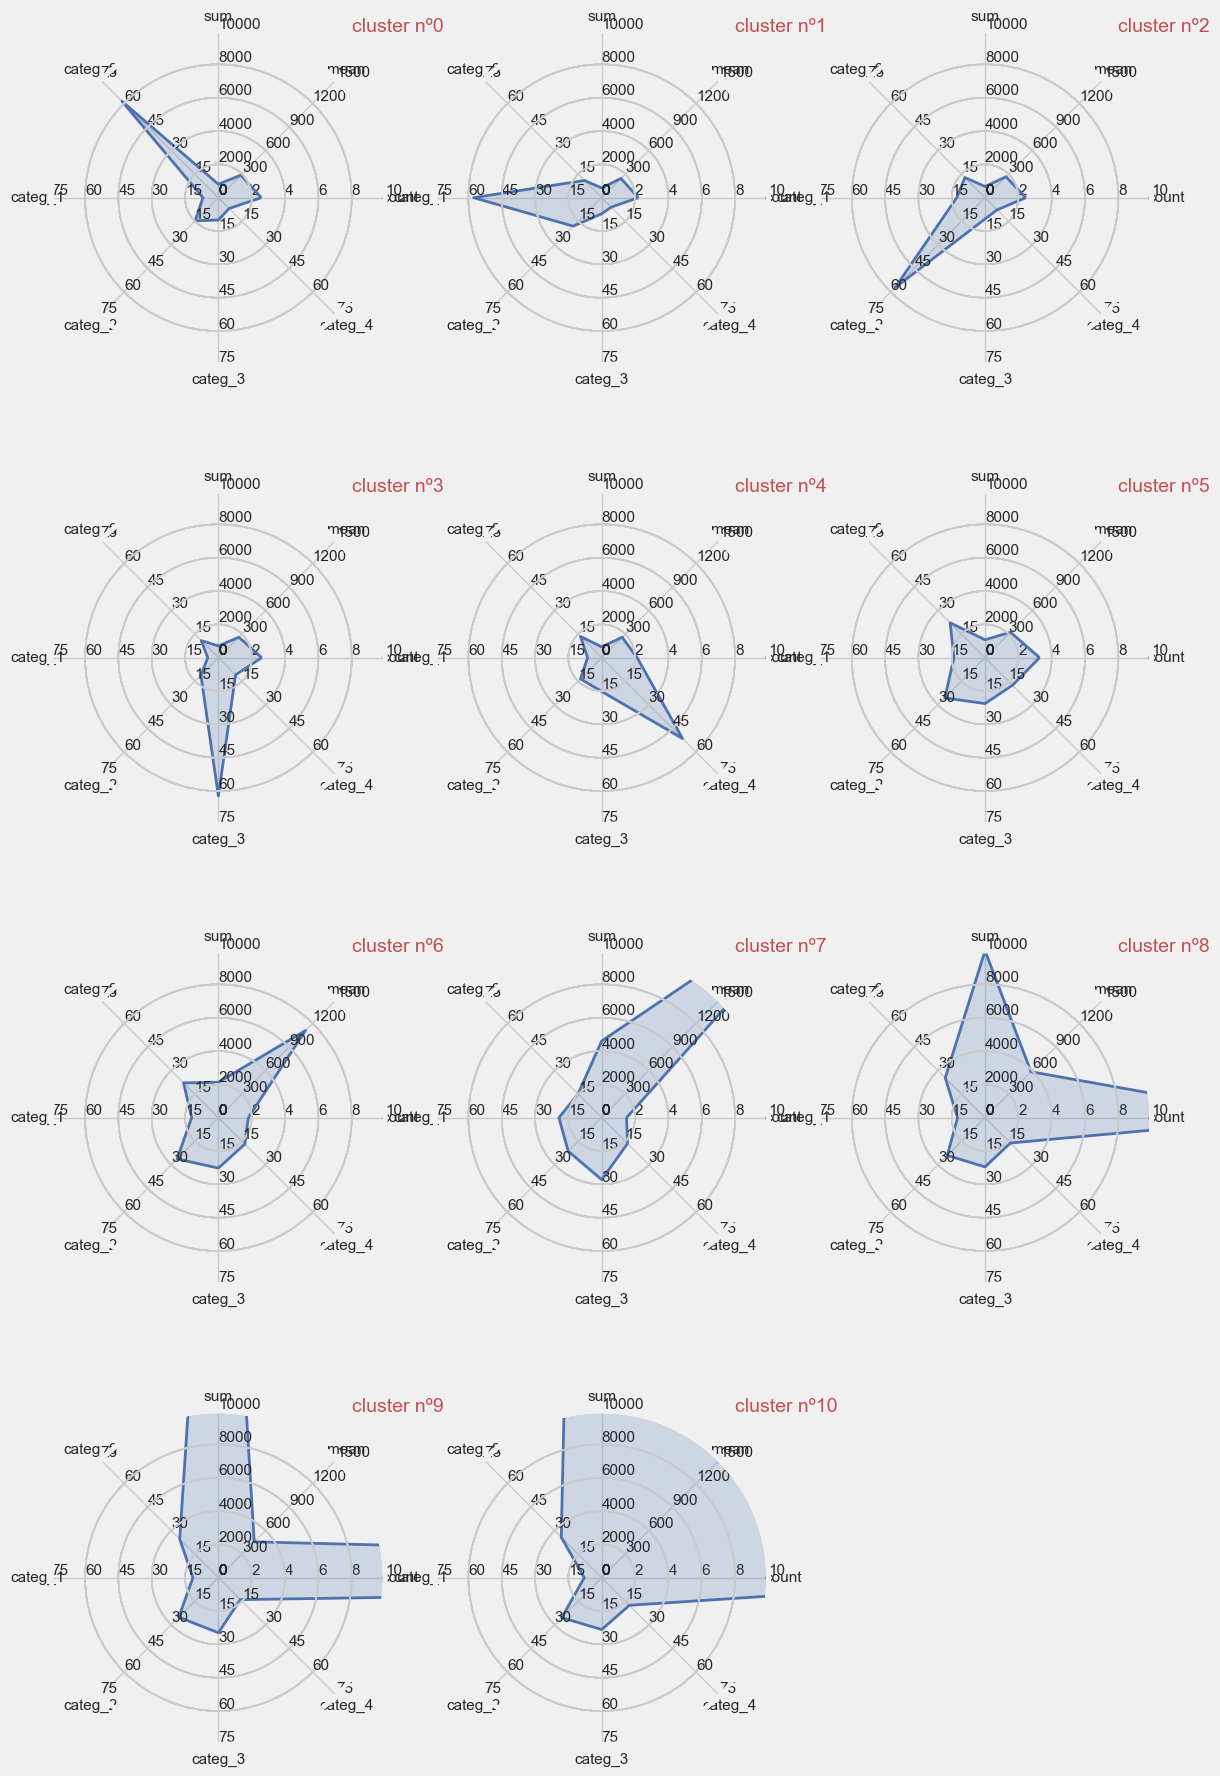

In [90]:
fig = plt.figure(figsize=(10,12))

attributes = ['count', 'mean', 'sum', 'categ_0', 'categ_1', 'categ_2', 'categ_3', 'categ_4']
ranges = [[0.01, 10], [0.01, 1500], [0.01, 10000], [0.01, 75], [0.01, 75], [0.01, 75], [0.01, 75], [0.01, 75]]
index  = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

n_groups = n_clusters ; i_cols = 3
i_rows = n_groups//i_cols
size_x, size_y = (1/i_cols), (1/i_rows)

for ind in range(n_clusters):
    ix = ind%3 ; iy = i_rows - ind//3
    pos_x = ix*(size_x + 0.05) ; pos_y = iy*(size_y + 0.05)            
    location = [pos_x, pos_y]  ; sizes = [size_x, size_y] 
    
    
    data = np.array(merged_df.loc[index[ind], attributes])    
    radar = RadarChart(fig, location, sizes, attributes, ranges)
    radar.plot(data, color = 'b', linewidth=2.0)
    radar.fill(data, alpha = 0.2, color = 'b')
    radar.title(title = 'cluster nº{}'.format(index[ind]), color = 'r')
    ind += 1

In [91]:
class Class_Fit(object):
    def __init__(self, clf, params=None):
        if params:            
            self.clf = clf(**params)
        else:
            self.clf = clf()
            
    # train on the x_train and y_train data
    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)
        
    # predict/validate on the held-out data
    def predict(self, x):
        return self.clf.predict(x)
    
    # hyperparameter tuning using GridsearchCV
    def grid_search(self, parameters, Kfold):
        self.grid = GridSearchCV(estimator = self.clf, param_grid = parameters, cv = Kfold)
    
    # fit after tuning
    def grid_fit(self, X, Y):
        self.grid.fit(X, Y)
    
    # predict
    def grid_predict(self, X, Y):
        self.predictions = self.grid.predict(X)
        print("Precision: {:.2f} % ".format(100*metrics.accuracy_score(Y, self.predictions)))

In [92]:
!pwd

/mnt/datassd/CodeHub/Science/CustomerSegmentation


In [133]:
columns = ['count', 'mean', 'sum', 'LastPurchase', 'categ_0', 'categ_1', 'categ_2', 'categ_3', 'categ_4']
X = selected_customers[columns]
Y = selected_customers['cluster']

In [134]:
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, train_size = 0.8, random_state=0)

In [135]:
X_train.shape, Y_train.shape

((2886, 9), (2886,))

In [136]:
X_test.shape, Y_test.shape

((722, 9), (722,))

In [137]:
svc = Class_Fit(clf = svm.LinearSVC)
svc.grid_search(parameters = [{'C':np.logspace(-2,2,10)}], Kfold = 5)

In [138]:
svc.grid_fit(X = X_train, Y = Y_train)

In [139]:
svc.grid_predict(X_test, Y_test)

Precision: 89.20 % 


In [140]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)
    
    
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


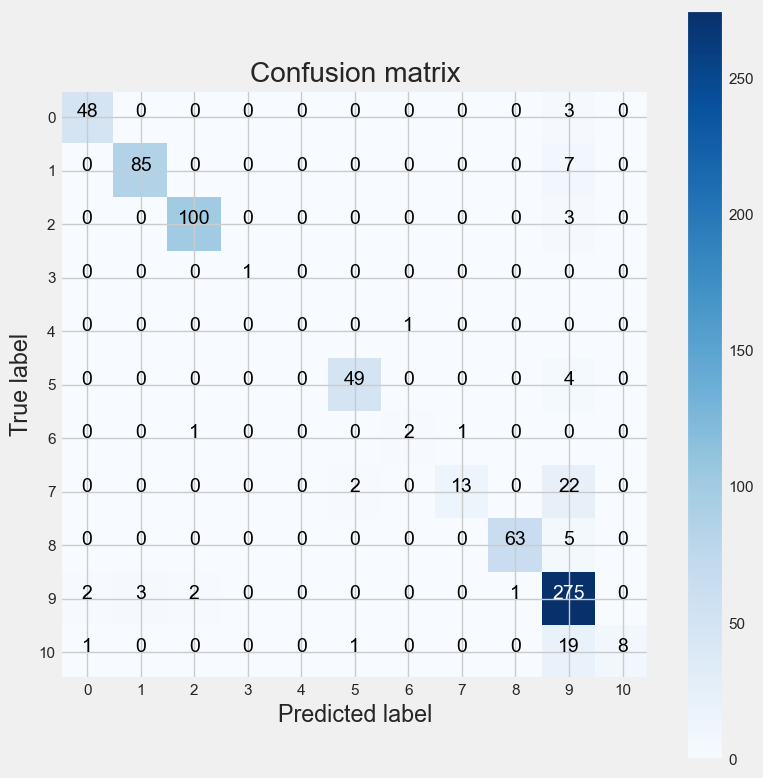

In [141]:

class_names = [i for i in range(11)]

cnf_matrix = confusion_matrix(Y_test, svc.predictions) 

np.set_printoptions(precision=2)

plt.figure(figsize = (8,8))

plot_confusion_matrix(cnf_matrix, classes=class_names, normalize = False, title='Confusion matrix')

In [142]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    
    """Generate a simple plot of the test and training learning curve"""
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

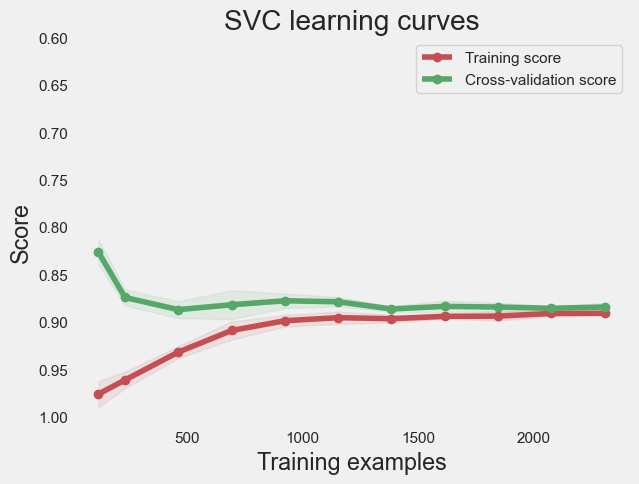

In [143]:
g = plot_learning_curve(svc.grid.best_estimator_,
                        "SVC learning curves", X_train, Y_train, ylim = [1.01, 0.6],
                        cv = 5,  train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5,
                                                0.6, 0.7, 0.8, 0.9, 1])

In [144]:
lr = Class_Fit(clf = linear_model.LogisticRegression)
lr.grid_search(parameters = [{'C':np.logspace(-2,2,20)}], Kfold = 5)

# fit on training data
lr.grid_fit(X = X_train, Y = Y_train)

# predict on test data
lr.grid_predict(X_test, Y_test)

Precision: 61.36 % 


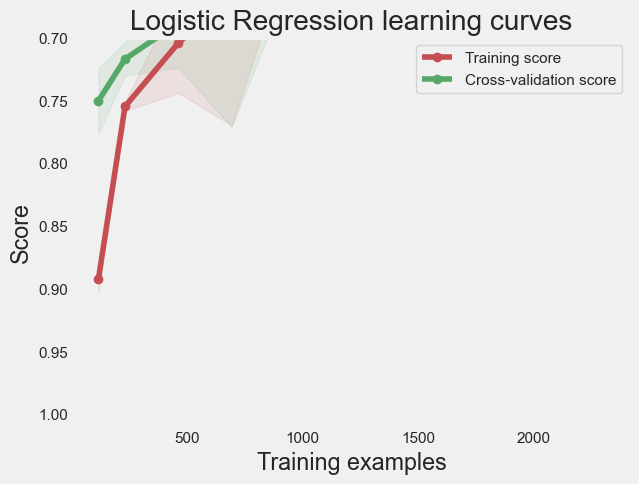

In [145]:
g = plot_learning_curve(lr.grid.best_estimator_, "Logistic Regression learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [146]:
knn = Class_Fit(clf = neighbors.KNeighborsClassifier)
knn.grid_search(parameters = [{'n_neighbors': np.arange(1,50,1)}], Kfold = 5)

# fit on training data
knn.grid_fit(X = X_train, Y = Y_train)

# predict on test data
knn.grid_predict(X_test, Y_test)

Precision: 62.47 % 


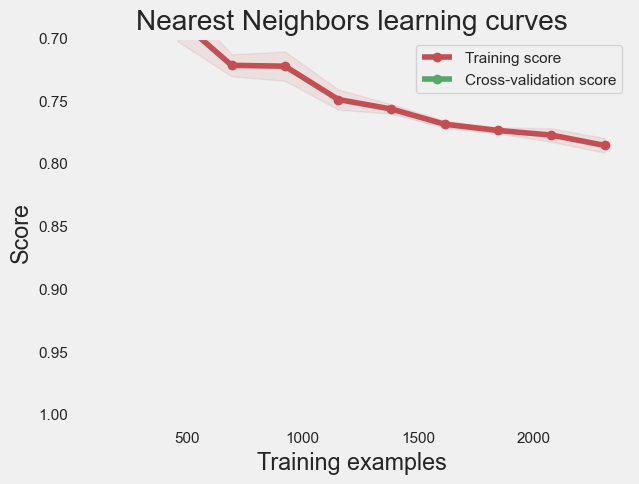

In [147]:
g = plot_learning_curve(knn.grid.best_estimator_, "Nearest Neighbors learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [148]:
tr = Class_Fit(clf = tree.DecisionTreeClassifier)
tr.grid_search(parameters = [{'criterion' : ['entropy', 'gini'], 'max_features' :['sqrt', 'log2']}], Kfold = 5)

# fit on training data
tr.grid_fit(X = X_train, Y = Y_train)

# predict on test data
tr.grid_predict(X_test, Y_test)

Precision: 92.94 % 


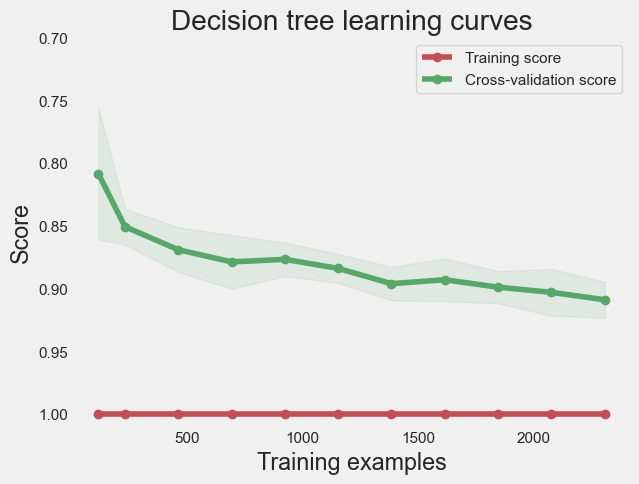

In [149]:
g = plot_learning_curve(tr.grid.best_estimator_, "Decision tree learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [150]:
rf = Class_Fit(clf = ensemble.RandomForestClassifier)
param_grid = {'criterion' : ['entropy', 'gini'], 'n_estimators' : [20, 40, 60, 80, 100],
               'max_features' :['sqrt', 'log2']}

rf.grid_search(parameters = param_grid, Kfold = 5)

# fit on training data
rf.grid_fit(X = X_train, Y = Y_train)

# predict on test data
rf.grid_predict(X_test, Y_test)

Precision: 94.88 % 


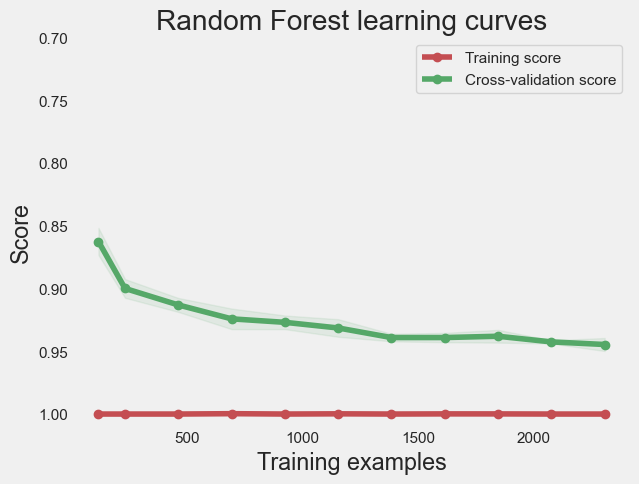

In [151]:
g = plot_learning_curve(rf.grid.best_estimator_, "Random Forest learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [152]:
ada = Class_Fit(clf = AdaBoostClassifier)
param_grid = {'n_estimators' : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}
ada.grid_search(parameters = param_grid, Kfold = 5)

# fit on training data
ada.grid_fit(X = X_train, Y = Y_train)

# predict on test data
ada.grid_predict(X_test, Y_test)

Precision: 70.36 % 


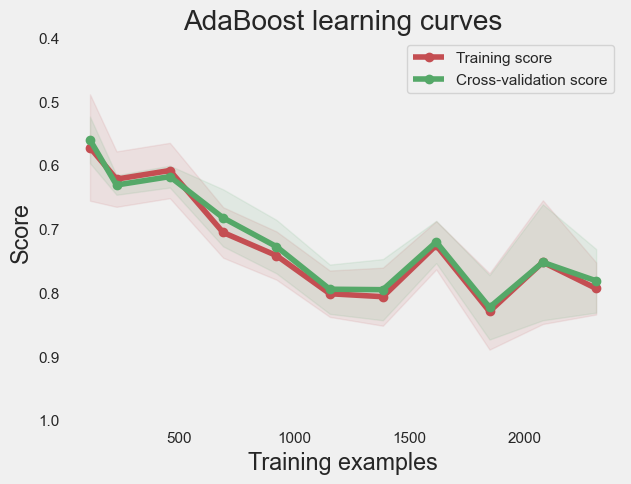

In [153]:
g = plot_learning_curve(ada.grid.best_estimator_, "AdaBoost learning curves", X_train, Y_train,
                        ylim = [1.01, 0.4], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [154]:
gb = Class_Fit(clf = ensemble.GradientBoostingClassifier)
param_grid = {'n_estimators' : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}
gb.grid_search(parameters = param_grid, Kfold = 5)

# fit on training data
gb.grid_fit(X = X_train, Y = Y_train)

# predict on test data
gb.grid_predict(X_test, Y_test)

Precision: 95.84 % 


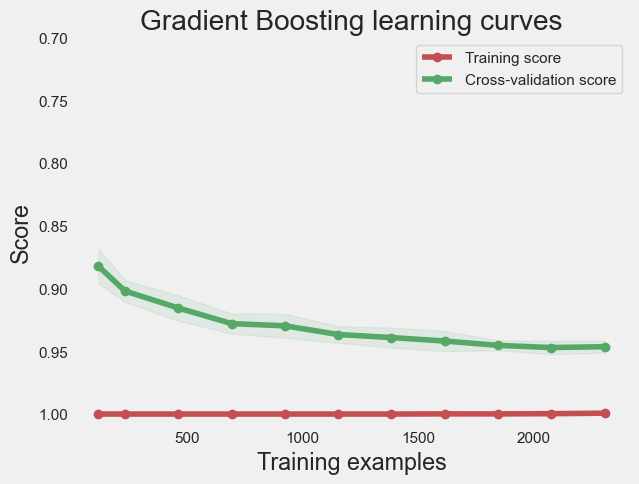

In [155]:
g = plot_learning_curve(gb.grid.best_estimator_, "Gradient Boosting learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [156]:
# random forest classifier best params
rf_best  = ensemble.RandomForestClassifier(**rf.grid.best_params_)

# gradient boosting classifier best params
gb_best  = ensemble.GradientBoostingClassifier(**gb.grid.best_params_)

# support vector classifier best params
svc_best = svm.LinearSVC(**svc.grid.best_params_)

# decision tree classifier best params
tr_best  = tree.DecisionTreeClassifier(**tr.grid.best_params_)

# k-nearest neighbor classifier best params
knn_best = neighbors.KNeighborsClassifier(**knn.grid.best_params_)

# logistics regression best params
lr_best  = linear_model.LogisticRegression(**lr.grid.best_params_)

In [157]:
votingC = ensemble.VotingClassifier(estimators=[('rf', rf_best),('gb', gb_best),('lr', lr_best)], voting='soft')

# Perform training
votingC = votingC.fit(X_train, Y_train)

# Finally, we can create a prediction for this model:
predictions = votingC.predict(X_test)
print("Precision: {:.2f} % ".format(100*metrics.accuracy_score(Y_test, predictions)))

Precision: 95.71 % 


In [158]:
basket_price = set_test.copy(deep = True)

In [159]:
transactions_per_user = basket_price.groupby(by=['CustomerID'])['Basket Price'].agg(['count','min','max','mean','sum'])
for i in range(5):
    col = 'categ_{}'.format(i)
    transactions_per_user.loc[:,col] = basket_price.groupby(by=['CustomerID'])[col].sum() /\
                                            transactions_per_user['sum']*100

    
transactions_per_user.reset_index(drop = False, inplace = True)
basket_price.groupby(by=['CustomerID'])['categ_0'].sum()

# Correcting time range
transactions_per_user['count'] = 5 * transactions_per_user['count']
transactions_per_user['sum']   = transactions_per_user['count'] * transactions_per_user['mean']

transactions_per_user.sort_values('CustomerID', ascending = True)[:5]

,CustomerID,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4
0,12347,10,224.82,1294.32,759.57,7595.70,32.343299,12.696657,20.017905,10.670511,24.271627
1,12349,5,1757.55,1757.55,1757.55,8787.75,12.245455,4.513101,26.506216,46.021450,10.713778
2,12352,5,311.73,311.73,311.73,1558.65,8.735123,6.672441,34.420813,42.953838,7.217785
3,12356,5,58.35,58.35,58.35,291.75,0.000000,0.000000,0.000000,100.000000,0.000000
4,12357,5,6207.67,6207.67,6207.67,31038.35,14.684737,5.089832,18.475531,33.399810,28.350089


In [160]:
list_cols = ['count', 'mean', 'sum', 'categ_0', 'categ_1', 'categ_2', 'categ_3', 'categ_4']

matrix_test = transactions_per_user[list_cols].to_numpy()
scaled_test_matrix = scaler.transform(matrix_test)

ValueError: X has 8 features, but StandardScaler is expecting 9 features as input.

In [ ]:
Y = kmeans.predict(scaled_test_matrix)

In [ ]:
columns = ['count','min','max','mean','categ_0','categ_1','categ_2','categ_3','categ_4']
X = transactions_per_user[columns]

In [ ]:
classifiers = [(svc, 'Support Vector Machine'),
                (lr, 'Logostic Regression'),
                (knn, 'k-Nearest Neighbors'),
                (tr, 'Decision Tree'),
                (rf, 'Random Forest'),
                (gb, 'Gradient Boosting')]

#
for clf, label in classifiers:
    print(30*'_', '\n{}'.format(label))
    clf.grid_predict(X, Y)